# **Generate Spot Height from Stereo Photogrammetry**

Thepchai Srinoi

Department of Survey Engineering

Chulalongkorn University

Download Image

In [ ]:
# https://drive.google.com/file/d/1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE/view?usp=drive_link
# https://drive.google.com/file/d/1UASR1p0yIWSedeL4liKmmU0SGgw70O0G/view?usp=drive_link

!gdown 1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE
!gdown 1UASR1p0yIWSedeL4liKmmU0SGgw70O0G

Downloading...
From (original): https://drive.google.com/uc?id=1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE
From (redirected): https://drive.google.com/uc?id=1ANrgP9evpdNsYUSnNjMgFhnzuZfdkrGE&confirm=t&uuid=11a32bdd-f76a-4571-804a-9934c58b24d7
To: /content/dmc_0683BW_32647.tif
100% 106M/106M [00:02<00:00, 48.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1UASR1p0yIWSedeL4liKmmU0SGgw70O0G
From (redirected): https://drive.google.com/uc?id=1UASR1p0yIWSedeL4liKmmU0SGgw70O0G&confirm=t&uuid=721909de-286a-4299-b5d3-20e43a7b92c8
To: /content/dmc_0684BW_32647.tif
100% 106M/106M [00:01<00:00, 87.3MB/s]


In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
img1 = cv.imread('/content/dmc_0683BW_32647.tif', cv.IMREAD_GRAYSCALE)

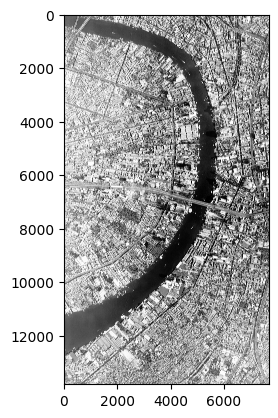

In [ ]:
plt.imshow( img1 , cmap = 'Greys_r' )

In [ ]:
img2 = cv.imread('/content/dmc_0684BW_32647.tif', cv.IMREAD_GRAYSCALE) #trainimage # right image

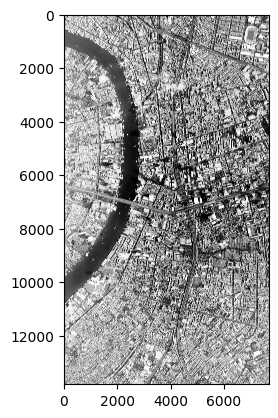

In [ ]:
plt.imshow( img2 , cmap = 'Greys_r' )

Crop Image ... Easy for Image Matching

In [ ]:
n_col = np.shape( img1 )[1]
n_row = np.shape( img1 )[0]
print(n_col, n_row)

7680 13824


In [ ]:
img1_cut = img1[int(0.24*n_row):int(0.28*n_row), int(0.7*n_col) :int(0.8*n_col)]

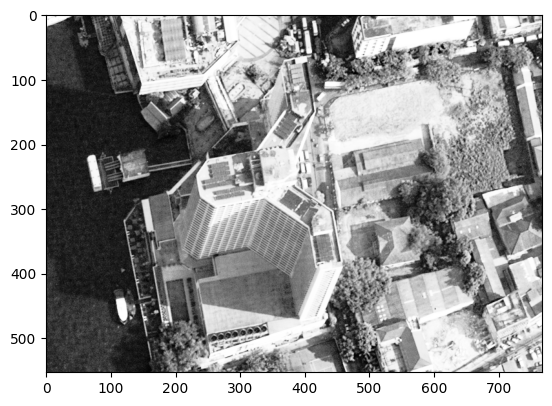

In [ ]:
plt.imshow( img1_cut , cmap = 'Greys_r' )

In [ ]:
img2_cut = img2[int(0.24*n_row):int(0.28*n_row), int(0.33*n_col): int(0.43*n_col)]

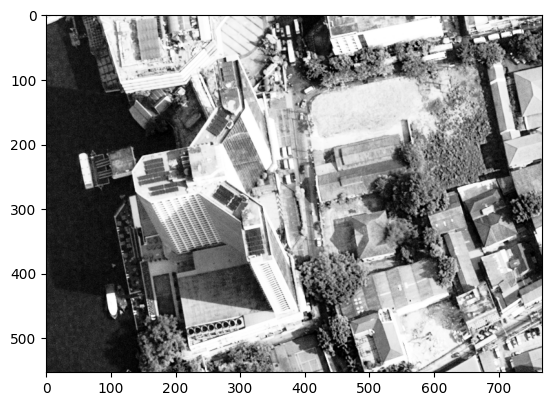

In [ ]:
plt.imshow( img2_cut , cmap = 'Greys_r' )

Keypoint Generation and Matching

In [ ]:
sift = cv.SIFT_create()
# find the keypoints and descriptors with SIFT
kp1, des1 = sift.detectAndCompute(img1_cut,None)
kp2, des2 = sift.detectAndCompute(img2_cut,None)

In [ ]:
# FLANN parameters
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks=50)
flann = cv.FlannBasedMatcher(index_params,search_params)
matches = flann.knnMatch(des1,des2,k=2)
pts1 = []
pts2 = []
# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.8*n.distance:
        pts2.append(kp2[m.trainIdx].pt)
        pts1.append(kp1[m.queryIdx].pt)

In [ ]:
len(pts2)

1180

In [ ]:
pts1 = np.float32(pts1)
pts2 = np.float32(pts2)
F, mask = cv.findFundamentalMat(pts1,pts2,cv.FM_LMEDS)
# We select only inlier points
pts1 = pts1[mask.ravel()==1]
pts2 = pts2[mask.ravel()==1]

In [ ]:
def drawlines(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c = img1.shape
    img1 = cv.cvtColor(img1,cv.COLOR_GRAY2BGR)
    img2 = cv.cvtColor(img2,cv.COLOR_GRAY2BGR)
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        img1 = cv.line(img1, (x0,y0), (x1,y1), color,1)
        img1 = cv.circle(img1,tuple(pt1),5,color,-1)
        img2 = cv.circle(img2,tuple(pt2),5,color,-1)
    return img1,img2

In [ ]:
pts1_int = np.int32(pts1)
pts2_int = np.int32(pts2)

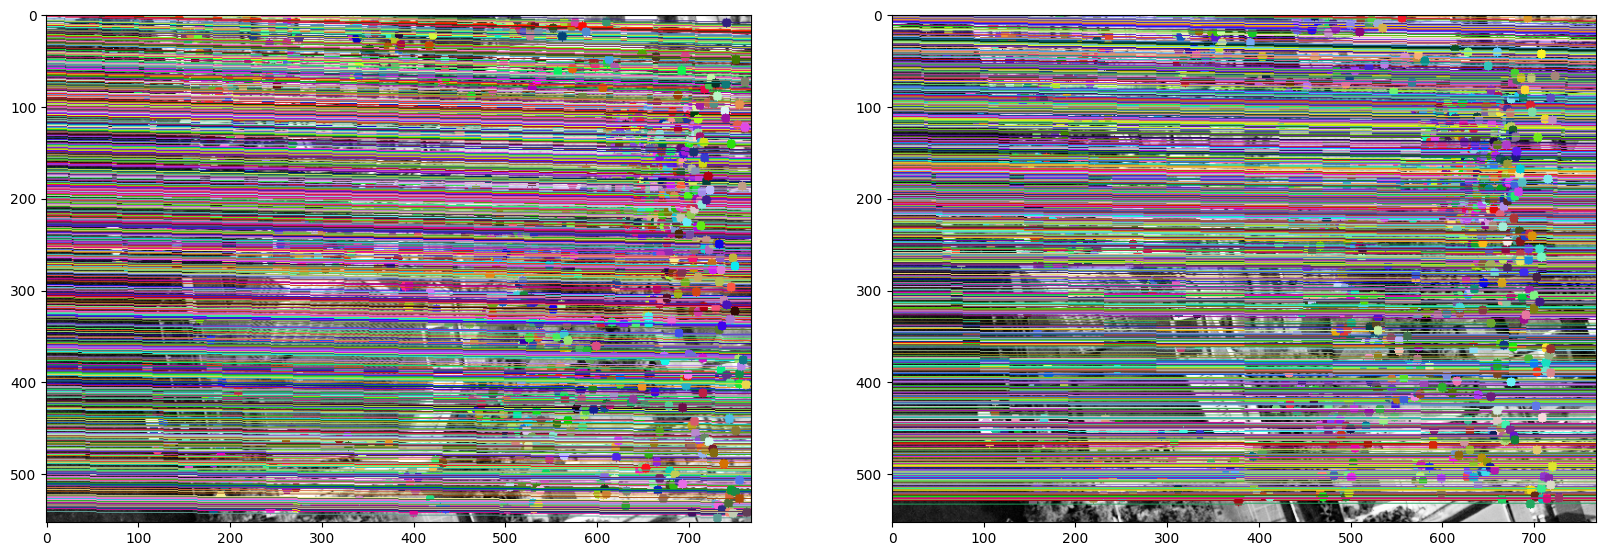

In [ ]:
from matplotlib.pyplot import figure

figure(figsize=(20, 40))

# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image
lines1 = cv.computeCorrespondEpilines(pts2_int.reshape(-1,1,2), 2,F)
lines1 = lines1.reshape(-1,3)
img5,img6 = drawlines(img1_cut,img2_cut,lines1,pts1_int,pts2_int)
# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv.computeCorrespondEpilines(pts1_int.reshape(-1,1,2), 1,F)
lines2 = lines2.reshape(-1,3)
img3,img4 = drawlines(img2_cut,img1_cut,lines2,pts2_int,pts1_int)
plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()

In [ ]:
def drawpoints(img1,img2,lines,pts1,pts2):
    ''' img1 - image on which we draw the epilines for the points in img2
        lines - corresponding epilines '''
    r,c = img1.shape
    img1 = cv.cvtColor(img1,cv.COLOR_GRAY2BGR)
    img2 = cv.cvtColor(img2,cv.COLOR_GRAY2BGR)
    for r,pt1,pt2 in zip(lines,pts1,pts2):
        color = tuple(np.random.randint(0,255,3).tolist())
        x0,y0 = map(int, [0, -r[2]/r[1] ])
        x1,y1 = map(int, [c, -(r[2]+r[0]*c)/r[1] ])
        #img1 = cv.line(img1, (x0,y0), (x1,y1), color,1)
        img1 = cv.circle(img1,tuple(pt1),5,color,-1)
        img2 = cv.circle(img2,tuple(pt2),5,color,-1)
    return img1,img2

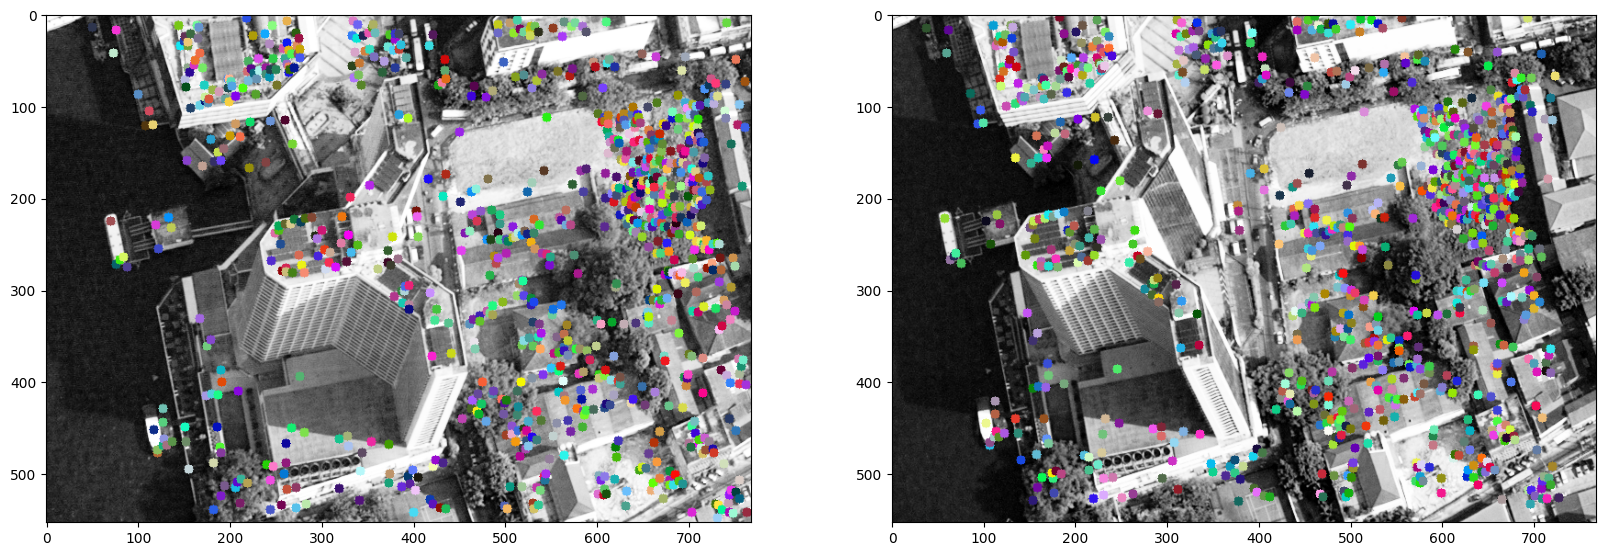

In [ ]:
# Find epilines corresponding to points in right image (second image) and
# drawing its lines on left image
figure(figsize=(20, 40))
lines1 = cv.computeCorrespondEpilines(pts2_int.reshape(-1,1,2), 2,F)
lines1 = lines1.reshape(-1,3)
img5,img6 = drawpoints(img1_cut,img2_cut,lines1,pts1_int,pts2_int)
# Find epilines corresponding to points in left image (first image) and
# drawing its lines on right image
lines2 = cv.computeCorrespondEpilines(pts1_int.reshape(-1,1,2), 1,F)
lines2 = lines2.reshape(-1,3)
img3,img4 = drawpoints(img2_cut,img1_cut,lines2,pts2_int,pts1_int)
plt.subplot(121),plt.imshow(img5)
plt.subplot(122),plt.imshow(img3)
plt.show()

pixel coordinate from image matching ...col, row

In [ ]:
pts1[800:801,:]

array([[689.79517, 347.80643]], dtype=float32)

In [ ]:
pts2[800:801,:]

array([[652.5701 , 336.71246]], dtype=float32)

caution!! crop image we crop row first, then crop col ...

use correct index ... col then row

In [ ]:
uv1 = pts1 + np.array([int(0.70*n_col),int(0.24*n_row)])
uv1[800:801,:]

array([[6065.79516602, 3664.806427  ]])

In [ ]:
uv2 = pts2 + np.array([int(0.33*n_col),int(0.24*n_row)])
uv2[800:801,:]

array([[3186.57012939, 3653.71246338]])

interior orientation transformation parameter

In [ ]:
# uv col row
# Transformation Parameter file (pix) to film (mm)
A0 = -46.0740
A1 = 0.012
A2 = 0
B0 = 82.9380
B1 = 0
B2 = -0.012

# x = A0 + A1c + A2r
# y = B0 + B1c + B2r

convert from pixel to image coordinate

In [ ]:
col = uv1[:,0]
row = uv1[:,1]

x = A0 + A1*col + A2*row
y = B0 + B1*col + B2*row

x = np.array( [x] ).T
y = np.array( [y] ).T

xy1 = np.concatenate( (x, y), axis=1)
xy1

array([[19.04796346, 42.95575256],
       [19.28780164, 40.42788776],
       [19.32271967, 42.62899274],
       ...,
       [27.57776733, 41.65377658],
       [27.58425366, 38.28744104],
       [27.60355444, 36.62634375]])

In [ ]:
col = uv2[:,0]
row = uv2[:,1]

x = A0 + A1*col + A2*row
y = B0 + B1*col + B2*row

x = np.array( [x] ).T
y = np.array( [y] ).T

xy2 = np.concatenate( (x, y), axis=1)
xy2

array([[-15.22194662,  42.95259139],
       [-14.97478574,  40.4635296 ],
       [-14.95402094,  42.6296391 ],
       ...,
       [ -7.03731299,  41.74236694],
       [ -7.05305713,  38.44642639],
       [ -6.94691016,  36.81696826]])

In [ ]:
n_data = np.shape( uv2 )[0]
n_data

982

constant value

In [ ]:
f = 120*1e-3

# EOP 0683

X0_L = 663307.387
Y0_L = 1517213.561
Z0_L = 3221.808
om_L = np.radians( 0.37213 )
ph_L = np.radians( 3.63363 )
kp_L = np.radians( 1.62283 )

eop1 = np.matrix([X0_L, Y0_L, Z0_L, om_L, ph_L, kp_L]).T

# EOP 0684
X0_R = 664232.352
Y0_R = 1517209.103
Z0_R = 3222.310
om_R = np.radians( 0.45831 )
ph_R = np.radians( 3.79946 )
kp_R = np.radians( 1.17540 )
eop2 = np.matrix([X0_R, Y0_R, Z0_R, om_R, ph_R, kp_R]).T


# Estimated Point Cloud Coordinate

Xpc = 664000.0
Ypc = 1517000.0
Zpc = 0
XX = np.matrix( [Xpc, Ypc, Zpc] ).T


# Rotation Matrix
def RotMatrix(ome, phi, kap) :
    coso = np.cos(ome)
    sino = np.sin(ome)
    cosp = np.cos(phi)
    sinp = np.sin(phi)
    cosk = np.cos(kap)
    sink = np.sin(kap)


    m11 = cosp*cosk
    m12 = coso*sink + sino*sinp*cosk
    m13 = sino*sink - coso*sinp*cosk
    m21 = -1*cosp*sink
    m22 = coso*cosk - sino*sinp*sink
    m23 =  sino*cosk + coso*sinp*sink
    m31 = sinp
    m32 = -1*sino*cosp
    m33 = coso*cosp
    return m11, m12, m13, m21, m22, m23, m31, m32, m33

# Estimated Functional Matrix
def Colinearity( obj_coord , EOP , f ) :

    X, Y, Z = ( float(val) for val in obj_coord.A1 )
    X0,Y0,Z0,ome,phi,kap = ( float(val) for val in EOP.A1 )

    m11, m12, m13, m21, m22, m23, m31, m32, m33 = RotMatrix(ome, phi, kap)

    U = m11*(X - X0) + m12*(Y - Y0) + m13*(Z - Z0)
    V = m21*(X - X0) + m22*(Y - Y0) + m23*(Z - Z0)
    W = m31*(X - X0) + m32*(Y - Y0) + m33*(Z - Z0)

    F1 = -f*(U/W)
    F2 = -f*(V/W)

    F = np.matrix([F1, F2]).T
    return F

Spot Height Production from Stereo Photogrammetry

In [ ]:
E_pos = []
N_pos = []
H_pos = []

for k in range( n_data ) :
  d = 1
  print(k)
  x_l = xy1[k,0]
  y_l = xy1[k,1]
  x_r = xy2[k,0]
  y_r = xy2[k,1]
  photo = np.matrix([ [ x_l,  y_l],
                      [ x_r,  y_r] ])*1e-3

  Lb = photo.flatten().T
  n_obs = len( Lb )
  n_par = 3
  delta = 0.1
  # Estimated Point Cloud Coordinate
  Xpc = 664000.0
  Ypc = 1517000.0
  Zpc = 0
  XX = np.matrix( [Xpc, Ypc, Zpc] ).T

  for l in range(5) :
    Fk = np.zeros([n_obs,1])
    Jk = np.zeros([n_obs, n_par])

    # Estimated Function Value
    FL = Colinearity(XX , eop1 , f )
    Fk[0:2,:] = FL

    FR = Colinearity(XX , eop2 , f )
    Fk[2:4,:] = FR

    delta = d

    # Form Jacobian Matrix
    FL1 = Colinearity(XX+ np.matrix([delta,0,0]).T , eop1 , f )
    FL2 = Colinearity(XX+ np.matrix([0,delta,0]).T , eop1 , f )
    FL3 = Colinearity(XX+ np.matrix([0,0,delta]).T , eop1 , f )

    FR1 = Colinearity(XX+ np.matrix([delta,0,0]).T , eop2 , f )
    FR2 = Colinearity(XX+ np.matrix([0,delta,0]).T , eop2 , f )
    FR3 = Colinearity(XX+ np.matrix([0,0,delta]).T , eop2 , f )

    JL1 = (FL1 - FL)/delta
    JL2 = (FL2 - FL)/delta
    JL3 = (FL3 - FL)/delta

    JR1 = (FR1 - FR)/delta
    JR2 = (FR2 - FR)/delta
    JR3 = (FR3 - FR)/delta

    #print('Jacobian Matrix')

    JkL = np.concatenate( (JL1, JL2, JL3) , axis = 1)
    JkR = np.concatenate( (JR1, JR2, JR3) , axis = 1)
    Jk = np.concatenate( (JkL, JkR) , axis = 0)


    # Least Square Adjustment
    Fk = np.matrix(Fk)
    Lb = np.matrix(Lb)
    Jk = np.matrix(Jk)

    A = Jk
    L = Fk - Lb

    N = np.matmul(A.transpose(), A)
    uu = np.matmul(A.transpose(), L)
    iN = np.linalg.inv(N)
    dX = -1*np.matmul(iN, uu)

    XX += dX

    v = np.matmul(A,dX) + L


    SSE = np.matmul(v.transpose(), v).item()
    RMSE = np.sqrt( SSE/( len(Lb) - n_par ) )

  e = XX[0].item()
  n = XX[1].item()
  h = XX[2].item()
  E_pos.append(e )
  N_pos.append(n)
  H_pos.append(h )
  print(' Object Coordinate ')
  print( 'X    ', XX[0].item() , 'm' )
  print( 'Y    ', XX[1].item() , 'm')
  print( 'Z    ', XX[2].item() , 'm')

0
 Object Coordinate 
X     663579.0925150422 m
Y     1518394.541718139 m
Z     3.792162741047536 m
1
 Object Coordinate 
X     663587.3308492568 m
Y     1518326.9156173086 m
Z     3.4588626920898884 m
2
 Object Coordinate 
X     663586.6213792294 m
Y     1518385.8355851423 m
Z     3.6283754314228673 m
3
 Object Coordinate 
X     663589.4773624617 m
Y     1518312.1913109838 m
Z     3.0343134579337865 m
4
 Object Coordinate 
X     663587.2227386385 m
Y     1518393.9166426857 m
Z     3.668100909788758 m
5
 Object Coordinate 
X     663590.8373712365 m
Y     1518313.5898499265 m
Z     3.1155494173796727 m
6
 Object Coordinate 
X     663591.8716159121 m
Y     1518314.18937518 m
Z     4.583525863239234 m
7
 Object Coordinate 
X     663593.5142630867 m
Y     1518310.7917411495 m
Z     3.401411935849231 m
8
 Object Coordinate 
X     663595.508087676 m
Y     1518371.251388012 m
Z     3.402153153480184 m
9
 Object Coordinate 
X     663598.4775319737 m
Y     1518360.4219989257 m
Z     3.493883323

Spot Height Calculation

In [ ]:
import pandas as pd
dick = {'E':E_pos, 'N':N_pos, 'H':H_pos}
df = pd.DataFrame(dick)
df

,E,N,H
0,663579.092515,1.518395e+06,3.792163
1,663587.330849,1.518327e+06,3.458863
2,663586.621379,1.518386e+06,3.628375
3,663589.477362,1.518312e+06,3.034313
4,663587.222739,1.518394e+06,3.668101
...,...,...,...
977,663805.706553,1.518278e+06,8.448299
978,663804.548141,1.518377e+06,2.827827
979,663804.319698,1.518360e+06,7.272989
980,663806.320630,1.518269e+06,10.988185


In [ ]:
import geopandas as gpd
from shapely.geometry import Point
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['E'], df['N']),
    crs="EPSG:32647"  # Set the CRS to WGS 84 / UTM zone 47N
)
print(gdf)
gdf.to_file("spotheight_correct.gpkg", driver="GPKG")
df.to_csv('spotheight_correct.csv')

                 E             N          H                        geometry
0    663579.092515  1.518395e+06   3.792163  POINT (663579.093 1518394.542)
1    663587.330849  1.518327e+06   3.458863  POINT (663587.331 1518326.916)
2    663586.621379  1.518386e+06   3.628375  POINT (663586.621 1518385.836)
3    663589.477362  1.518312e+06   3.034313  POINT (663589.477 1518312.191)
4    663587.222739  1.518394e+06   3.668101  POINT (663587.223 1518393.917)
..             ...           ...        ...                             ...
977  663805.706553  1.518278e+06   8.448299  POINT (663805.707 1518278.452)
978  663804.548141  1.518377e+06   2.827827  POINT (663804.548 1518377.269)
979  663804.319698  1.518360e+06   7.272989   POINT (663804.32 1518359.792)
980  663806.320630  1.518269e+06  10.988185   POINT (663806.321 1518269.11)
981  663809.177851  1.518227e+06   3.516120  POINT (663809.178 1518227.354)

[982 rows x 4 columns]


In [ ]:
# prompt: visualized turbo color of circle varied by height (0 to 10 m) in attribute ... folium map

import folium
from branca.colormap import LinearColormap

# Assuming 'gdf' is your GeoDataFrame with 'H' (height) column
# and geometry column containing Point objects

# Create a Turbo colormap
colormap = LinearColormap(['blue', 'cyan', 'green', 'yellow', 'red'], vmin=0, vmax=30)

m = folium.Map(location=[13.72956490746323, 100.51297712251237], zoom_start=20)

tile = folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Esri Satellite',
    overlay=False,
    control=True
).add_to(m)

for _, r in gdf.iterrows():
    color = colormap(r["H"])
    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x],  # Use y, x for latitude, longitude
        radius=5,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.6,
        popup=f"{r['H']:.3f} m"
    ).add_to(m)

# Add the colormap legend to the map
colormap.caption = 'Height (m)'
m.add_child(colormap)


m


THE END !!!!!!!!!